In [18]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [19]:
fstream = open('bank-full.csv', 'r')
file_text = fstream.readlines()
fstream.close()

In [20]:
labels = []
for line in file_text[1:]:
    line = line.strip().replace('"', '').split(';')
    labels.append(line[-1])

In [21]:
features = []
for row in file_text [1:]:
    row = row.strip().replace('"', '').split(';')
    features.append(row[:-1])

In [22]:
labels = np.array(labels)
features = np.array(features)
switch = np.where(labels == 'no', -1, 1)

In [23]:
for col in range(features.shape[1]):
    try:
        features[:, col].astype(float)
    except ValueError:
        values = {}
        for value in np.unique(features[:, col]):
            values[value] = len(values)
        features[:, col] = [values[x] for x in features[:, col]]
features = features.astype(float)
features, testFeatures, switch, testSwitch = train_test_split(features, switch, test_size=0.2, random_state=42, stratify=switch)

In [24]:
classifiers = 200
trainErrors = np.zeros(classifiers)
weights = np.ones(features.shape[0]) / features.shape[0]
models = []
modelWeights = []
for i in range(classifiers):
    stump = DecisionTreeClassifier(max_depth=1)
    stump.fit(features, switch, sample_weight=weights)
    predictions = stump.predict(features)
    trainErrors[i] += np.mean(predictions != switch)
    error = np.sum(weights * (predictions != switch)) / np.sum(weights)
    modelWeight = 0.5 * np.log((1 - error) / (error + 1e-10))
    weights *= np.exp(-modelWeight * switch * predictions)
    weights /= np.sum(weights)  
    models.append(stump)
    modelWeights.append(modelWeight)


In [25]:
singleTree = DecisionTreeClassifier(max_depth=1)
singleTree.fit(features, switch)
singleTreeError = np.mean(singleTree.predict(features) != switch)

In [26]:
trainError = []
boostPredictions = np.sign(sum(w * m.predict(features) for m, w in zip(models, modelWeights)))
currentError = np.mean(boostPredictions != switch)
trainError.append(currentError)

In [27]:
finalPredictions = np.zeros(testFeatures.shape[0])
for model, weight in zip(models, modelWeights):
    finalPredictions += weight * model.predict(testFeatures)
finalPredictions = np.sign(finalPredictions)
testError = np.mean(finalPredictions != testSwitch)
print('Training error:', currentError, 'Testing error:', testError)

Training error: 0.10102853351028533 Testing error: 0.10284197721994913


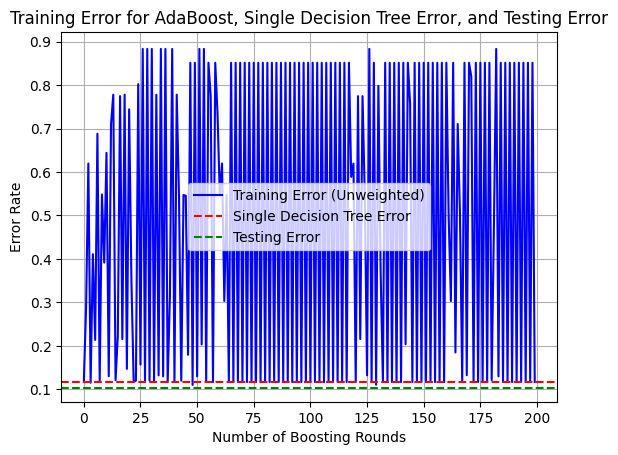

In [28]:
testError = np.mean(finalPredictions != testSwitch)
plt.plot(range(classifiers), trainErrors, label='Training Error (Unweighted)', color='blue')
plt.axhline(y=singleTreeError, color='red', linestyle='--', label='Single Decision Tree Error')
plt.axhline(y=testError, color='green', linestyle='--', label='Testing Error')
plt.xlabel('Number of Boosting Rounds')
plt.ylabel('Error Rate')
plt.title('Training Error for AdaBoost, Single Decision Tree Error, and Testing Error')
plt.legend()
plt.grid()
plt.show()